In [2]:
# flagging invoice
## vendor invoices can be fraud or hyper inflated : manually reviewing invoices is time consuming , we created a model to flag such invoices with 
1.abnormal cost
2.freight
3.delivery patterns
this indicates errors, disputes or compliance risks
this reduces financial risks
improve operational efficiency
priortize human review where essential
this automated invoce flagging system enables the finance teams to overveiw high risk invoices while allowing the
low risk invoices to be [processed automatically


SyntaxError: invalid decimal literal (1443122021.py, line 3)

In [4]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [5]:
conn=sqlite3.connect("C:\\Users\\Kabir\\Desktop\\my SALES ANALYSIS\\data\\inventory.db")


In [6]:
table_names=pd.read_sql_query("select name from sqlite_master where type='table'" ,conn)
table_names


,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,vendor_invoice
5,vendor_sales_summary
6,purchase_agg_df


In [7]:
for table in table_names['name']:
    display(table)
    display(pd.read_sql_query(
        f"select * from {table} limit 5"
        
        ,conn))
    

'begin_inventory'

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


'end_inventory'

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


'purchases'

...

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


'vendor_sales_summary'

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


'purchase_agg_df'

,index,PONumber,total_brands,total_quantity,total_dollars,average_receiving_delay
0,0,8106,81,10100,137483.78,12.614130
1,1,8107,2,24,348.72,12.500000
2,2,8108,165,8466,60281.13,12.632479
3,3,8109,23,2246,14298.09,12.626866
4,4,8110,183,8086,56493.23,12.695271


In [9]:
purchase_agg_df=pd.read_sql_query("select p.PONumber,count(distinct p.Brand) as total_brands,sum(p.Quantity) as total_quantity,sum(p.Dollars) as total_dollars,avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as average_receiving_delay from purchases p group by p.PONumber",conn)
                    

In [10]:
agg_vendor_invoice_df=pd.read_sql_query("""

select
v.PONumber,
v.Quantity as invoice_quantity,
v.Dollars as invoice_dollars,
v.Freight,
(julianday(v.InvoiceDate)-julianday(v.PODate)) as days_po_to_invoice,
(julianday(v.PayDate)-julianday(v.InvoiceDate)) as payment_delay
from vendor_invoice v
""",conn)

In [11]:
purchase_agg_df

,PONumber,total_brands,total_quantity,total_dollars,average_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [12]:
agg_vendor_invoice_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,payment_delay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [13]:
purchase_agg_df.to_sql("purchase_agg_df",conn,if_exists="replace")

5543

In [16]:
agg_vendor_invoice_df.to_sql("agg_vendor_invoice_df",conn,if_exists="replace")

5543

In [17]:
pd.read_sql_query("select name from sqlite_master where type='table'",conn)

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,vendor_invoice
5,vendor_sales_summary
6,purchase_agg_df
7,agg_vendor_invoice_df


In [18]:
pd.read_sql_query("""
select * from purchase_agg_df p
left join agg_vendor_invoice_df v
on p.PONumber=v.PONumber
""",conn)

,index,PONumber,total_brands,total_quantity,total_dollars,average_receiving_delay,index,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,payment_delay
0,0,8106,81,10100,137483.78,12.614130,3,8106,10100,137483.78,2935.20,23.0,24.0
1,1,8107,2,24,348.72,12.500000,10,8107,24,348.72,9.08,16.0,36.0
2,2,8108,165,8466,60281.13,12.632479,14,8108,8466,60281.13,1549.81,22.0,30.0
3,3,8109,23,2246,14298.09,12.626866,17,8109,2246,14298.09,408.72,23.0,30.0
4,4,8110,183,8086,56493.23,12.695271,22,8110,8086,56493.23,1300.92,20.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5538,5538,13657,3,253,3844.39,4.870968,5526,13657,65,1248.61,5.74,17.0,41.0
5539,5539,13658,111,14115,102949.38,5.016349,5532,13658,38896,502128.05,2761.70,18.0,40.0
5540,5540,13659,13,338,2492.20,4.735294,5533,13659,195,2599.66,11.70,12.0,37.0
5541,5541,13660,12,195,2599.66,4.611111,5537,13660,60,694.68,3.20,15.0,43.0


In [19]:
cursor=conn.cursor()
cursor.execute("DROP TABLE IF EXISTS agg_vendor_invoice_df")
conn.commit()

In [8]:
df=pd.read_sql_query("""
with purchase_agg as(
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_quantity,sum(p.Dollars) as total_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as average_receiving_delay 
from purchases p group by p.PONumber
)
select
v.PONumber,
v.Quantity as invoice_quantity,
v.Dollars as invoice_dollars,
v.Freight,
(julianday(v.InvoiceDate)-julianday(v.PODate)) as days_po_to_invoice,
(julianday(v.PayDate)-julianday(v.InvoiceDate)) as payment_delay,
pa.total_brands,
pa.total_quantity,
pa.total_dollars,
pa.average_receiving_delay
from vendor_invoice v
left join purchase_agg as pa
on v.PONumber=pa.PONumber


""",conn)

In [9]:
#checking null and datatypes
df.isnull().sum()

PONumber                   0
invoice_quantity           0
invoice_dollars            0
Freight                    0
days_po_to_invoice         0
payment_delay              0
total_brands               0
total_quantity             0
total_dollars              0
average_receiving_delay    0
dtype: int64

In [10]:
df.dtypes

PONumber                     int64
invoice_quantity             int64
invoice_dollars            float64
Freight                    float64
days_po_to_invoice         float64
payment_delay              float64
total_brands                 int64
total_quantity               int64
total_dollars              float64
average_receiving_delay    float64
dtype: object

In [11]:
#we create labels for classification
def create_invoice_risk_label(row):
    if (abs(row["invoice_dollars"]-row["total_dollars"])>5):
        return 1
    if row["average_receiving_delay"]>10:
        return 1
    return 0
df["flag_invoice"]=df.apply(create_invoice_risk_label,axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

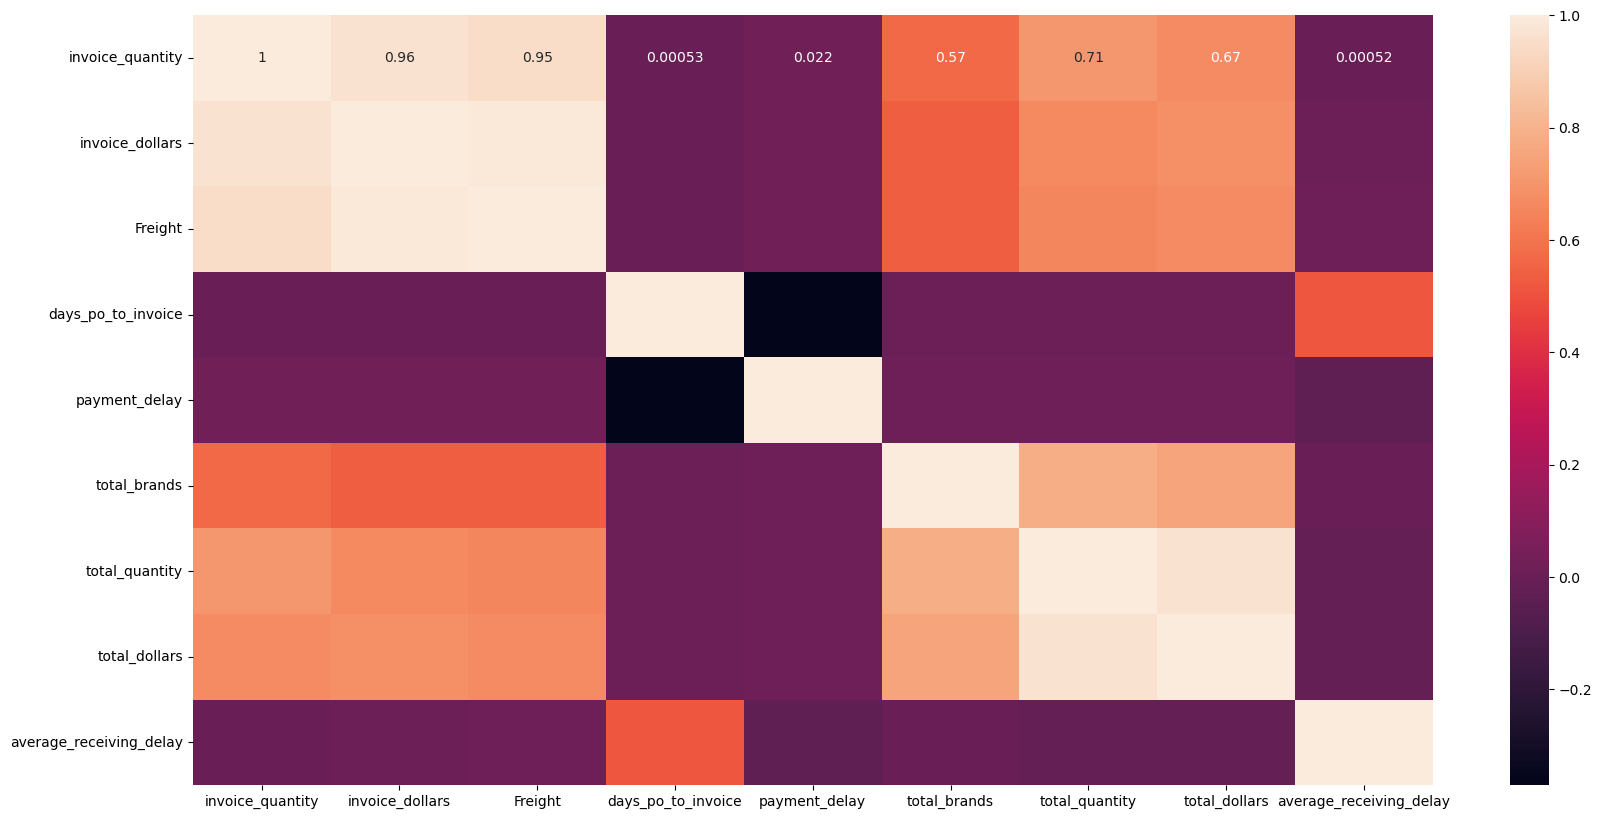

In [25]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)
plt.show()

In [26]:
#creating groups
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [22]:
significant_features=[]
non_significant_features=[]

In [12]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,payment_delay,total_brands,total_quantity,total_dollars,average_receiving_delay,flag_invoice
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,1
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,1
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000,0
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,1
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809,0
...,...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795,1
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500,1
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000,1
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541,1


In [26]:
X=df[['invoice_quantity','invoice_dollars','total_quantity','total_dollars','average_receiving_delay']]
y=df['flag_invoice']

In [46]:
X.describe().round()



,invoice_quantity,invoice_dollars,total_quantity,total_dollars,average_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,6059.0,58073.0,8.0
std,14453.0,140234.0,14453.0,140234.0,2.0
min,1.0,4.0,1.0,4.0,3.0
25%,83.0,968.0,83.0,968.0,6.0
50%,423.0,4765.0,423.0,4765.0,8.0
75%,5100.0,44587.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,141660.0,1660436.0,13.0


AttributeError: 'DataFrame' object has no attribute 'dtype'

In [14]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2)

In [15]:
#data is not scaled . lets scale it
from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaler=StandardScaler()
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.fit_transform(xtest)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
model1=LogisticRegression()
model1.fit(xtrain_scaled,ytrain)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(xtrain_scaled,ytrain)

model3=RandomForestClassifier(random_state=42)
model3.fit(xtrain_scaled,ytrain)

RandomForestClassifier(random_state=42)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

def evaluate_model(model, X_test, y_test,model_name):
    
    y_pred = model.predict(X_test)
    print("model name \n", model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [19]:
evaluate_model(model1, xtest_scaled,ytest,'LogisticRegression')
evaluate_model(model2,xtest_scaled,ytest,'DecisionTreeClassifier')
evaluate_model(model3,xtest_scaled,ytest,'RandomForestClassifier')

model name 
 LogisticRegression
Accuracy: 0.7619477006311993
Precision: 0.7738693467336684
Recall: 0.4128686327077748

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       736
           1       0.77      0.41      0.54       373

    accuracy                           0.76      1109
   macro avg       0.77      0.68      0.69      1109
weighted avg       0.76      0.76      0.74      1109

model name 
 DecisionTreeClassifier
Accuracy: 0.6708746618575293
Precision: 0.5061919504643962
Recall: 0.8766756032171582

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.57      0.70       736
           1       0.51      0.88      0.64       373

    accuracy                           0.67      1109
   macro avg       0.70      0.72      0.67      1109
weighted avg       0.77      0.67      0.68      1109

model name 
 RandomForestClassifier
Accuracy: 0.7096483318

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

random_search.fit(xtrain_scaled, ytrain)

best_model = random_search.best_estimator_

evaluate_model(best_model, xtest_scaled, ytest, "best model for randomforestclassifier")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
model name 
 best model for randomforestclassifier
Accuracy: 0.7159603246167718
Precision: 0.5496575342465754
Recall: 0.8605898123324397

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.64      0.75       736
           1       0.55      0.86      0.67       373

    accuracy                           0.72      1109
   macro avg       0.73      0.75      0.71      1109
weighted avg       0.78      0.72      0.72      1109



In [39]:
xtest_scaled.shape

(1109, 7)

In [25]:

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": "balanced",
        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model,
        xtrain_scaled,
        ytrain,
        cv=3,
        scoring="f1"
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params

best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(xtrain_scaled, ytrain)

evaluate_model(best_model, xtest_scaled, ytest, "Optuna RF")

[I 2026-03-18 13:07:04,103] A new study created in memory with name: no-name-585bcb4c-0513-4024-8280-0349fabddde1
[I 2026-03-18 13:07:10,776] Trial 0 finished with value: 0.9291858567404204 and parameters: {'n_estimators': 65, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.9291858567404204.
[I 2026-03-18 13:07:40,885] Trial 1 finished with value: 0.9467353552596762 and parameters: {'n_estimators': 260, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9467353552596762.
[I 2026-03-18 13:08:04,702] Trial 2 finished with value: 0.9455631763111088 and parameters: {'n_estimators': 209, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.9467353552596762.
[I 2026-03-18 13:08:23,601] Trial 3 finished with value: 0.9500463753210955 and parameters: {'n_estimators': 166, 'max_depth': 24, 'm

model name 
 Optuna RF
Accuracy: 0.7114517583408476
Precision: 0.5454545454545454
Recall: 0.8525469168900804

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.64      0.75       736
           1       0.55      0.85      0.67       373

    accuracy                           0.71      1109
   macro avg       0.72      0.75      0.71      1109
weighted avg       0.78      0.71      0.72      1109



In [40]:
xtrain_scaled.shape

(4434, 7)

In [1]:
model3.fit(X_train, y_train)
import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
print(feat_imp.sort_values(ascending=False))

NameError: name 'model3' is not defined

In [56]:
from sklearn.metrics import confusion_matrix

In [59]:
confusion_matrix(model3.predict(xtest_scaled),ytest)

array([[729,  78],
       [  4, 298]], dtype=int64)